In [1]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Imports loaded.")

Imports loaded.


In [2]:
CORPUS = [
    {
        "id": "palsgraf_1928",
        "case_name": "Palsgraf v. Long Island Railroad Co.",
        "year": 1928,
        "court": "New York Court of Appeals",
        "topic": "proximate_cause",
        "liability_outcome": "NOT_LIABLE",
        "text": """FACTS: Mrs. Palsgraf was standing on a platform of the defendant's railroad after buying a ticket to travel to Rockaway Beach. A man carrying a package ran to catch a train that was moving slowly out of the station. A railroad guard on the car reached forward to help the man board, and another guard on the platform pushed him from behind. In doing so, the guard dislodged a package the man was carrying. The package contained fireworks, which exploded when they fell to the rails. The shock of the explosion threw down some scales at the other end of the platform, injuring the plaintiff Mrs. Palsgraf.

REASONING: The conduct of the defendant's guard, if a wrong in its relation to the holder of the package, was not a wrong in its relation to the plaintiff standing far away. Negligence is not actionable unless it involves the invasion of a legally protected interest — the violation of a right. In strict propriety, the plaintiff sues in her own right for a wrong personal to her, and not as the vicarious beneficiary of a breach of duty to another. The risk reasonably to be perceived defines the duty to be obeyed, and risk imports relation; it is risk to another or to others within the range of apprehension. This does not mean, of course, that one who launches a destructive force is always relieved of liability if the force, though known to be destructive, pursues an unexpected path. It was not necessary that the defendant should have had notice of the particular method in which an accident would occur, if the possibility of an accident was clear to the ordinarily prudent eye. Here, by concession, there was nothing in the situation to suggest to the most cautious mind that the parcel wrapped in newspaper would spread wreckage through the station.

HOLDING: The court held that the railroad was NOT liable to Mrs. Palsgraf. The defendant's duty of care did not extend to the plaintiff because her injury was not a foreseeable result of the guard's negligent actions toward the package carrier. Proximate cause requires a relationship between the negligent act and the plaintiff — the plaintiff must be within the orbit of danger as disclosed to the eye of reasonable vigilance.

DISSENT: Judge Andrews dissenting: We are told that one who drives at reckless speed through a crowded city street is guilty of a negligent act and therefore of a wrongful one irrespective of the consequences. Negligence in the air will not do. We are all exposed to the acts of our fellows. The question of proximate cause is one of expediency. There is in truth little to guide us other than common sense. Every cause has its effect. We draw an uncertain and wavering line, but draw it we must as best we can. The railroad was the proximate cause of the plaintiff's injury and should be held liable for all direct consequences of its employees' negligent act.""",
        "holding_keywords": ["not liable", "not extend", "foreseeable", "orbit of danger"],
        "dissent_keywords": ["andrews", "liable", "proximate cause", "common sense"]
    },
    {
        "id": "wagon_mound_1961",
        "case_name": "Overseas Tankship v. Morts Dock (Wagon Mound No. 1)",
        "year": 1961,
        "court": "Privy Council",
        "topic": "proximate_cause",
        "liability_outcome": "NOT_LIABLE",
        "text": """FACTS: The defendants' ship, the Wagon Mound, was taking on furnace oil at a wharf in Sydney Harbour. Through the negligence of the defendants' employees, a large quantity of furnace oil was spilled into the harbour. The oil spread across the water to a wharf some distance away where the plaintiffs were carrying out welding work. The plaintiffs' manager was advised that the oil could be ignited and took precautions, but was told by an expert that furnace oil floating on water would not ignite. Two days after the spill, molten metal from welding operations fell into the water and ignited cotton waste floating in the oil. The resulting fire destroyed the plaintiffs' wharf and two ships docked there.

REASONING: It is not the act but the consequences on which tortious liability is founded. Just as there is no longer any need to think of liability in terms of culpa, so there is no longer any value in searching for a degree of identity between the facts of this case and the facts of some previous case. The essential factor in determining liability is whether the damage is of such a kind as the reasonable man should have foreseen. The Polemis rule, which subjected a defendant to liability for all direct consequences however unforeseeable, is fundamentally unsound and should no longer be applied. Liability is not unlimited and must be determined by what a reasonable person would have foreseen at the time of the negligent act. The defendants could not reasonably have foreseen that furnace oil floating on water would ignite, as this was contrary to the expert opinion available at the time.

HOLDING: The defendants were NOT liable for the fire damage to the wharf and ships. The correct test for remoteness of damage is reasonable foreseeability. Since the defendants could not reasonably have foreseen that furnace oil floating on water would catch fire, the fire damage was too remote a consequence of their negligent spillage of oil to impose liability.

DISSENT: This was a unanimous Privy Council decision with no formal dissent. The board expressly overruled the direct consequences test from Re Polemis, replacing it with the reasonable foreseeability standard that now governs remoteness of damage throughout the common law world.""",
        "holding_keywords": ["not liable", "foreseeability", "too remote", "not reasonably foreseen"],
        "dissent_keywords": ["no dissent", "unanimous", "overruled", "polemis"]
    },
    {
        "id": "polemis_1921",
        "case_name": "Re Polemis and Furness Withy & Co.",
        "year": 1921,
        "court": "Court of Appeal",
        "topic": "proximate_cause",
        "liability_outcome": "LIABLE",
        "text": """FACTS: The charterers of a ship employed Arab stevedores to unload cargo from the vessel Polemis in the port of Casablanca. While moving cargo, the stevedores negligently knocked a plank into the hold of the ship. The impact of the plank caused a spark, which ignited petrol vapour that had accumulated in the hold. The resulting fire completely destroyed the ship. The owners of the ship claimed the full value of the vessel from the charterers as damages for the negligent act of the stevedores.

REASONING: The act of negligence which caused the fire was the dropping of the plank into the hold. It was admitted that the stevedores were negligent and that the dropping of the plank was the direct cause of the fire. The question is whether the defendants are liable for all the consequences of the negligent act or only for those consequences that were foreseeable. Where an act is negligent and damage results directly from that negligent act, the defendant is liable for all direct consequences of the act, even if those consequences could not have been anticipated at the time. The foreseeability of the specific type of damage is irrelevant once negligence causing some damage has been established.

HOLDING: The charterers WERE liable for the full loss of the ship. Once negligence is established and damage is a direct consequence of that negligence, the defendant is liable for all direct consequences regardless of whether those specific consequences were foreseeable. The direct consequences rule governs liability and foreseeability of the particular type of damage is not required.

DISSENT: No formal dissent was recorded in this decision. However, the direct consequences test established in Polemis was subsequently criticized as producing unjust results and was expressly overruled by the Privy Council in Overseas Tankship v. Morts Dock in 1961.""",
        "holding_keywords": ["were liable", "direct consequence", "foreseeability irrelevant", "full loss"],
        "dissent_keywords": ["no dissent", "criticized", "overruled", "unjust"]
    },
    {
        "id": "blyth_1856",
        "case_name": "Blyth v. Birmingham Waterworks Co.",
        "year": 1856,
        "court": "Court of Exchequer",
        "topic": "negligence_standard",
        "liability_outcome": "NOT_LIABLE",
        "text": """FACTS: The defendant waterworks company had installed a fire plug near the plaintiff's house many years before. The plug was made according to the best known principles and was maintained in proper order. During an exceptionally severe frost — described as the most severe in living memory — the plug thawed and the escaping water flooded the plaintiff's house causing considerable damage. The plaintiff brought an action for negligence, arguing that the company had failed to maintain the plug properly.

REASONING: Negligence is the omission to do something which a reasonable man, guided upon those considerations which ordinarily regulate the conduct of human affairs, would do; or doing something which a prudent and reasonable man would not do. The defendants had done everything that a reasonable man could require. The company installed the plug according to the best known principles. The frost was so severe that it would be unreasonable to require the company to have anticipated it. The standard of care required is that of a reasonable person acting in ordinary circumstances, not a standard requiring precautions against every conceivable contingency including extraordinary events.

HOLDING: The defendant waterworks company was NOT liable for the flood damage. The damage was caused by an extraordinary and unprecedented frost which the defendants could not reasonably have foreseen or guarded against. The objective standard of negligence requires a defendant to act as a reasonable person would act in ordinary circumstances. Acting reasonably does not require guarding against events that fall outside the range of ordinary anticipation.

DISSENT: The case was decided without formal dissent. The unanimous judgment established the objective reasonable person standard for negligence that remains foundational to tort law today.""",
        "holding_keywords": ["not liable", "extraordinary", "not reasonably foreseen", "reasonable person"],
        "dissent_keywords": ["no dissent", "unanimous", "objective standard", "foundational"]
    },
    {
        "id": "hughes_1963",
        "case_name": "Hughes v. Lord Advocate",
        "year": 1963,
        "court": "House of Lords",
        "topic": "proximate_cause",
        "liability_outcome": "LIABLE",
        "text": """FACTS: Post Office employees left an open manhole in a Edinburgh street unattended overnight, surrounded by a canvas shelter and four paraffin warning lamps. Two young boys, aged eight and ten, took one of the lamps and descended into the manhole with it. When leaving, one of the boys knocked the lamp into the manhole. An explosion occurred — caused by paraffin vapour igniting in an unusual way that no one could have predicted — and the boy fell into the hole suffering severe burns.

REASONING: The defendants were negligent in leaving the manhole unattended and accessible. The question is whether the particular way in which the harm occurred was sufficiently foreseeable to establish liability. It is not necessary that the precise concatenation of circumstances should be foreseeable — only that harm of the relevant type should be foreseeable. The type of harm here was personal injury from burning, which was entirely foreseeable given the presence of lighted lamps near an unattended opening. The fact that the injury occurred in an unusual manner — through an explosion rather than ordinary burning — does not break the chain of causation when injury from burning was foreseeable.

HOLDING: The defendants WERE liable for the boy's injuries. It is sufficient that the type of harm — personal injury from burning — was foreseeable, even if the precise manner in which the burning occurred was unusual and unforeseeable. A defendant need not foresee the precise way in which harm will occur, only that harm of that general type is a foreseeable consequence of negligence.

DISSENT: There was no formal dissent in the House of Lords decision. The judgment clarified the relationship between Wagon Mound foreseeability and the manner in which harm occurs, establishing that type foreseeability is sufficient even when the precise mechanism is unexpected.""",
        "holding_keywords": ["were liable", "type of harm", "foreseeable", "manner"],
        "dissent_keywords": ["no dissent", "clarified", "type foreseeability", "mechanism"]
    },
    {
        "id": "barnett_1969",
        "case_name": "Barnett v. Chelsea and Kensington Hospital",
        "year": 1969,
        "court": "Queen's Bench Division",
        "topic": "causation",
        "liability_outcome": "NOT_LIABLE",
        "text": """FACTS: Three night watchmen attended the casualty department of the defendant hospital after drinking tea and becoming ill with vomiting. The duty doctor, himself unwell, declined to see them and told them to go home and call their own doctors. One of the watchmen, Mr. Barnett, died approximately five hours later from arsenical poisoning. His widow brought an action for negligence against the hospital, arguing that the doctor's failure to examine and treat her husband caused his death.

REASONING: There is no doubt that the hospital owed the deceased a duty of care and that the duty was breached when the doctor failed to examine the patient. However, the question of causation requires separate analysis. Even if the doctor had examined the deceased and administered treatment, the arsenical poisoning was so advanced and so severe that it is virtually certain the deceased would have died in any event. The standard treatment for arsenic poisoning, had it been initiated immediately, would not have saved the deceased given the amount of poison consumed and the time elapsed.

HOLDING: The hospital was NOT liable for the death of Mr. Barnett. Even though the hospital breached its duty of care by failing to examine and treat him, that breach did not cause his death. The test for causation requires that the breach be a but-for cause of the damage — that but for the breach, the damage would not have occurred. Since the deceased would have died even with proper treatment, the breach of duty did not cause the death.

DISSENT: The case was decided without dissent. The judgment is a foundational authority on the distinction between breach of duty and causation in medical negligence cases, establishing that a claimant must prove on the balance of probabilities that the breach caused the harm.""",
        "holding_keywords": ["not liable", "but-for", "did not cause", "would have died"],
        "dissent_keywords": ["no dissent", "foundational", "balance of probabilities", "medical negligence"]
    },
    {
        "id": "donoghue_1932",
        "case_name": "Donoghue v. Stevenson",
        "year": 1932,
        "court": "House of Lords",
        "topic": "duty_of_care",
        "liability_outcome": "LIABLE",
        "text": """FACTS: Mrs. Donoghue's friend purchased a bottle of ginger beer manufactured by Stevenson from a café in Paisley. Mrs. Donoghue drank part of the contents and her friend then poured the remainder into a glass, revealing a decomposed snail. Mrs. Donoghue suffered gastroenteritis and nervous shock as a result. She could not sue in contract as she had not purchased the drink herself, so she brought an action in negligence directly against the manufacturer.

REASONING: The law must keep pace with the decisions of men of business and their practice. The question is whether the manufacturer of a product owes a duty of care to the ultimate consumer with whom he has no contractual relationship. The answer must be found in the general principle of who is my neighbour. You must take reasonable care to avoid acts or omissions which you can reasonably foresee would be likely to injure your neighbour. The rule that you are to love your neighbour becomes in law: you must not injure your neighbour. Who then in law is my neighbour? The answer seems to be persons who are so closely and directly affected by my act that I ought reasonably to have them in contemplation as being so affected when I am directing my mind to the acts or omissions in question.

HOLDING: The manufacturer WAS liable to the ultimate consumer even in the absence of a contract. A manufacturer of products owes a duty of care to the consumer who uses those products if there is no reasonable possibility of intermediate examination. The neighbour principle establishes that a duty of care arises whenever harm to a person is a reasonably foreseeable consequence of one's actions.

DISSENT: Lords Buckmaster and Tomlin dissenting: The decision extends negligence liability beyond any previously recognized boundary. The existing law required a contractual relationship or a recognized special duty. To extend liability to all foreseeable consequences without any limiting principle will expose manufacturers to indeterminate liability. The majority creates a principle so broad that its consequences cannot be controlled.""",
        "holding_keywords": ["was liable", "duty of care", "neighbour principle", "reasonable foreseeability"],
        "dissent_keywords": ["buckmaster", "tomlin", "extends", "indeterminate liability", "no limiting principle"]
    },
    {
        "id": "overseas_tankship_2_1967",
        "case_name": "Overseas Tankship v. The Miller Steamship (Wagon Mound No. 2)",
        "year": 1967,
        "court": "Privy Council",
        "topic": "proximate_cause",
        "liability_outcome": "LIABLE",
        "text": """FACTS: This case arose from the same oil spill as Wagon Mound No. 1, but was brought by different plaintiffs — the owners of two ships damaged in the fire rather than the wharf owners. The key factual difference was the evidence presented: in this case, evidence was led that the defendants' engineers actually knew that the furnace oil could ignite under certain conditions, even if they regarded ignition as unlikely.

REASONING: The question here is whether a risk of ignition, even if regarded as small, was sufficient to impose liability. A reasonable man would not dismiss a real risk as negligible simply because it was small. The practical question is whether the risk was so small that a reasonable man would feel justified in disregarding it having regard to the magnitude of the precaution that would have been required to eliminate it. The risk of the oil igniting was real. The precaution required — pumping the oil back on board — was not onerous. A reasonable man, knowing of a real risk, however small, is not justified in ignoring it when the precaution against it is easy to take.

HOLDING: The defendants WERE liable to the ship owners. Even a small foreseeable risk of damage is sufficient to impose liability in negligence if the precaution against it is not unreasonably onerous. The distinction from Wagon Mound No. 1 is the evidence: here the defendants knew of a real risk of ignition, making the damage foreseeable even if unlikely.

DISSENT: The Privy Council decision was unanimous. The judgment reconciled Wagon Mound No. 1 and No. 2 by clarifying that foreseeability does not require probability — a real risk, however small, is sufficient if the precaution is reasonable.""",
        "holding_keywords": ["were liable", "real risk", "foreseeable", "precaution not onerous"],
        "dissent_keywords": ["unanimous", "reconciled", "real risk", "probability not required"]
    },
    {
        "id": "cambridge_water_1994",
        "case_name": "Cambridge Water Co. v. Eastern Counties Leather",
        "year": 1994,
        "court": "House of Lords",
        "topic": "strict_liability",
        "liability_outcome": "NOT_LIABLE",
        "text": """FACTS: Eastern Counties Leather used a chemical solvent in its tanning process. Over many years, small quantities of the solvent had been spilled on the floor of the factory and had percolated through the soil, eventually contaminating a borehole used by Cambridge Water to supply drinking water. At the time of the spillages, it was not known or foreseeable that such contamination would result. Cambridge Water sought compensation under the rule in Rylands v. Fletcher or in negligence.

REASONING: The rule in Rylands v. Fletcher imposes strict liability for the escape of dangerous things brought onto land in the course of non-natural use. However, the House of Lords held that foreseeability of harm is required even under the rule in Rylands v. Fletcher — the defendant must have been able to foresee that harm of the relevant type might result from the escape. This brings Rylands v. Fletcher liability in line with the general principles of negligence. The unforeseeable contamination of the water supply through percolation underground was not foreseeable at the time of the spillages.

HOLDING: The defendant was NOT liable under either negligence or the rule in Rylands v. Fletcher. Foreseeability of harm is a prerequisite for liability under Rylands v. Fletcher as well as in negligence. Since the contamination of a distant water supply by percolation was not foreseeable at the time of the chemical spillages, there was no liability.

DISSENT: The House of Lords decision was unanimous. The judgment significantly developed the law by importing the foreseeability requirement into Rylands v. Fletcher liability, bringing strict liability closer to the general framework of negligence law.""",
        "holding_keywords": ["not liable", "not foreseeable", "foreseeability required", "no liability"],
        "dissent_keywords": ["unanimous", "developed", "importing foreseeability", "strict liability"]
    },
    {
        "id": "smith_v_leech_1962",
        "case_name": "Smith v. Leech Brain & Co.",
        "year": 1962,
        "court": "Queen's Bench Division",
        "topic": "thin_skull_rule",
        "liability_outcome": "LIABLE",
        "text": """FACTS: The plaintiff's husband was employed by the defendant company. While working, a piece of molten metal splashed from a tank and burned his lip. The burn activated a pre-malignant condition in his lip which developed into cancer, from which he died three years later. The defendant argued that cancer and death were not foreseeable consequences of a minor burn and therefore too remote.

REASONING: The defendants were negligent in exposing the deceased to the risk of being burned by molten metal. The question is whether the defendants are liable for the full extent of the damage, including the cancer that developed from the burn. The thin skull rule provides that a tortfeasor must take his victim as he finds him. If the type of harm is foreseeable — here, burn injury — then the defendant is liable for the full extent of the harm even if that harm is more severe than would be expected in a normal person because of a pre-existing condition. The test is not whether the full extent of the damage was foreseeable but whether the type of damage was foreseeable.

HOLDING: The defendants WERE liable for the full extent of the damage including the cancer and death. The thin skull rule applies: once a burn injury is foreseeable, the defendant is liable for all consequences flowing from that burn, including the activation of a pre-existing malignant condition and subsequent death. The eggshell skull principle means a defendant must take the victim as they find him.

DISSENT: The case was decided without dissent. The judgment applies and extends the thin skull rule in the context of the Wagon Mound foreseeability test, establishing that type foreseeability combined with the thin skull rule can produce liability for damage of a type or extent that was not itself foreseeable.""",
        "holding_keywords": ["were liable", "thin skull", "take victim as found", "full extent"],
        "dissent_keywords": ["no dissent", "extends", "eggshell skull", "type foreseeability"]
    }
]

print(f"Corpus loaded: {len(CORPUS)} court opinions")
print(f"\nCase list:")
for op in CORPUS:
    print(f"  {op['year']} — {op['case_name']} [{op['liability_outcome']}]")

Corpus loaded: 10 court opinions

Case list:
  1928 — Palsgraf v. Long Island Railroad Co. [NOT_LIABLE]
  1961 — Overseas Tankship v. Morts Dock (Wagon Mound No. 1) [NOT_LIABLE]
  1921 — Re Polemis and Furness Withy & Co. [LIABLE]
  1856 — Blyth v. Birmingham Waterworks Co. [NOT_LIABLE]
  1963 — Hughes v. Lord Advocate [LIABLE]
  1969 — Barnett v. Chelsea and Kensington Hospital [NOT_LIABLE]
  1932 — Donoghue v. Stevenson [LIABLE]
  1967 — Overseas Tankship v. The Miller Steamship (Wagon Mound No. 2) [LIABLE]
  1994 — Cambridge Water Co. v. Eastern Counties Leather [NOT_LIABLE]
  1962 — Smith v. Leech Brain & Co. [LIABLE]


In [3]:
print("\n" + "="*50)
print("CORPUS ANALYSIS")
print("="*50)

section_lengths = {"FACTS": [], "REASONING": [], "HOLDING": [], "DISSENT": []}

for opinion in CORPUS:
    text = opinion["text"]
    sections = {"FACTS": "", "REASONING": "", "HOLDING": "", "DISSENT": ""}
    current = None
    for line in text.strip().split('\n'):
        line = line.strip()
        if not line:
            continue
        for s in sections:
            if line.upper().startswith(s + ":"):
                current = s
                sections[s] += line[len(s)+1:].strip() + " "
                break
        else:
            if current:
                sections[current] += line + " "
    
    for s, content in sections.items():
        section_lengths[s].append(len(content.split()))

print(f"\nAverage word counts per section:")
for section, lengths in section_lengths.items():
    avg = np.mean(lengths)
    mn = np.min(lengths)
    mx = np.max(lengths)
    print(f"  {section:<12}: avg={avg:.0f} words  (min={mn}, max={mx})")

print(f"\nKey insight:")
print(f"  HOLDING sections avg {np.mean(section_lengths['HOLDING']):.0f} words")
print(f"  At 512 tokens (~380 words), most HOLDINGS fit in one chunk")
print(f"  But REASONING sections avg {np.mean(section_lengths['REASONING']):.0f} words")
print(f"  Fixed-size chunking will fragment REASONING across 2-3 chunks")
print(f"  Those fragments will score high similarity to HOLDING queries")
print(f"  This is the structural setup for the failure in notebook 03.")



CORPUS ANALYSIS

Average word counts per section:
  FACTS       : avg=83 words  (min=63, max=118)
  REASONING   : avg=126 words  (min=96, max=201)
  HOLDING     : avg=64 words  (min=56, max=80)
  DISSENT     : avg=48 words  (min=25, max=117)

Key insight:
  HOLDING sections avg 64 words
  At 512 tokens (~380 words), most HOLDINGS fit in one chunk
  But REASONING sections avg 126 words
  Fixed-size chunking will fragment REASONING across 2-3 chunks
  Those fragments will score high similarity to HOLDING queries
  This is the structural setup for the failure in notebook 03.


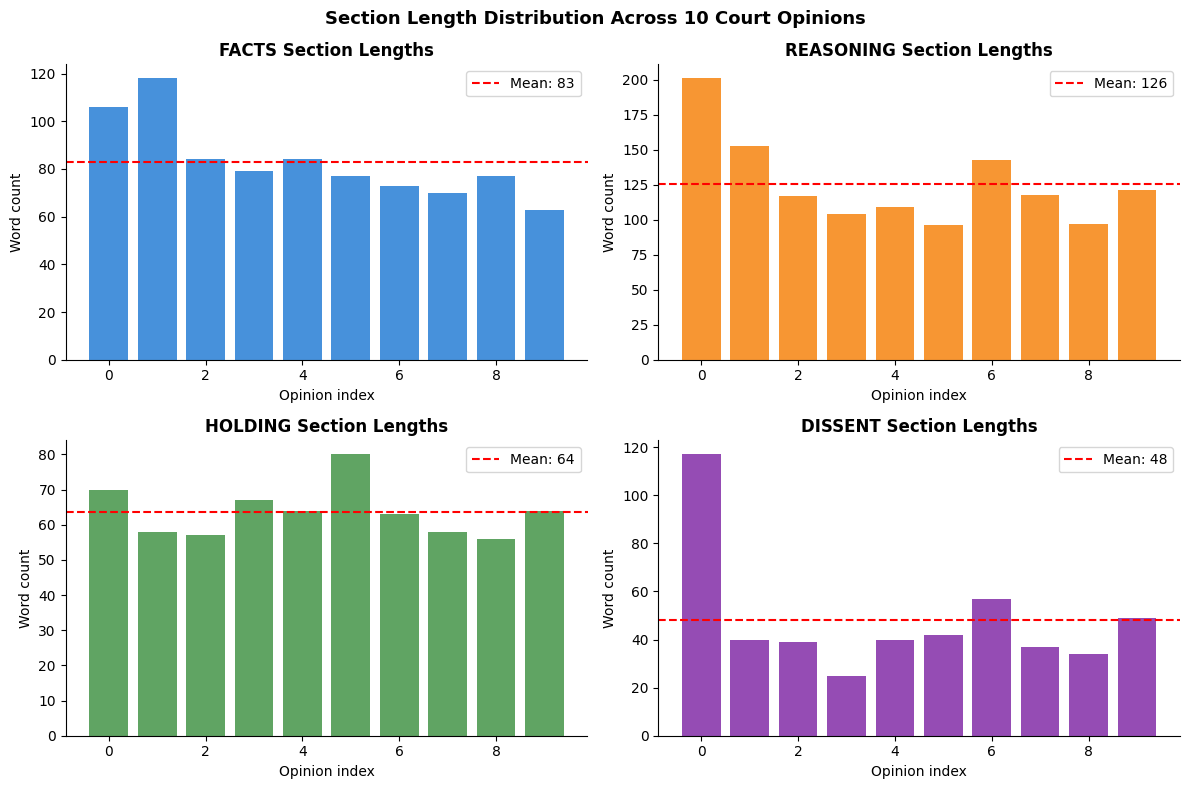

Corpus analysis figure saved.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = {'FACTS': '#1976d2', 'REASONING': '#f57c00',
          'HOLDING': '#388e3c', 'DISSENT': '#7b1fa2'}

for i, (section, lengths) in enumerate(section_lengths.items()):
    axes[i].bar(range(len(lengths)), lengths,
                color=colors[section], alpha=0.8)
    axes[i].axhline(y=np.mean(lengths), color='red',
                    linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
    axes[i].set_title(f'{section} Section Lengths', fontweight='bold')
    axes[i].set_xlabel('Opinion index')
    axes[i].set_ylabel('Word count')
    axes[i].legend()
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Section Length Distribution Across 10 Court Opinions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/corpus_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Corpus analysis figure saved.")

In [5]:
QUERIES = [
    {
        "id": "q1",
        "text": "What did the court hold regarding the railroad's liability to Mrs. Palsgraf?",
        "target_opinion": "palsgraf_1928",
        "correct_section": "HOLDING"
    },
    {
        "id": "q2",
        "text": "What was the court's ruling on whether the Wagon Mound defendants were liable for fire damage?",
        "target_opinion": "wagon_mound_1961",
        "correct_section": "HOLDING"
    },
    {
        "id": "q3",
        "text": "How did the court decide the charterers' liability for destroying the ship Polemis?",
        "target_opinion": "polemis_1921",
        "correct_section": "HOLDING"
    },
    {
        "id": "q4",
        "text": "What did the court hold about the waterworks company's liability for flood damage?",
        "target_opinion": "blyth_1856",
        "correct_section": "HOLDING"
    },
    {
        "id": "q5",
        "text": "What was the ruling on the Post Office's liability for the boy's injuries from the manhole explosion?",
        "target_opinion": "hughes_1963",
        "correct_section": "HOLDING"
    },
    {
        "id": "q6",
        "text": "How did the court rule on the hospital's liability for the patient's death from arsenical poisoning?",
        "target_opinion": "barnett_1969",
        "correct_section": "HOLDING"
    },
    {
        "id": "q7",
        "text": "What did the court hold about the snail in the ginger beer and the manufacturer's duty of care?",
        "target_opinion": "donoghue_1932",
        "correct_section": "HOLDING"
    },
    {
        "id": "q8",
        "text": "What was the court's holding on liability for the small foreseeable risk of oil ignition in Wagon Mound No. 2?",
        "target_opinion": "overseas_tankship_2_1967",
        "correct_section": "HOLDING"
    },
    {
        "id": "q9",
        "text": "What did the court decide about liability for the unforeseeable chemical contamination of the water supply?",
        "target_opinion": "cambridge_water_1994",
        "correct_section": "HOLDING"
    },
    {
        "id": "q10",
        "text": "What was the ruling on liability for cancer caused by a workplace burn activating a pre-existing condition?",
        "target_opinion": "smith_v_leech_1962",
        "correct_section": "HOLDING"
    }
]

print(f"Query set defined: {len(QUERIES)} holding queries")
print("Each query requires the court's HOLDING — not reasoning, not dissent.")

Query set defined: 10 holding queries
Each query requires the court's HOLDING — not reasoning, not dissent.


In [6]:
processed = {
    "corpus": CORPUS,
    "queries": QUERIES,
    "metadata": {
        "total_opinions": len(CORPUS),
        "total_queries": len(QUERIES),
        "topic": "proximate cause in tort law",
        "ground_truth_section": "HOLDING",
        "avg_holding_words": float(np.mean(section_lengths["HOLDING"])),
        "avg_reasoning_words": float(np.mean(section_lengths["REASONING"]))
    }
}

with open('data/processed/corpus.json', 'w') as f:
    json.dump(processed, f, indent=2)

print("\nCorpus saved to data/processed/corpus.json")
print(f"  {len(CORPUS)} opinions")
print(f"  {len(QUERIES)} queries")
print(f"\nStatus: READY TO PROCEED TO NOTEBOOK 02")
print("="*50)


Corpus saved to data/processed/corpus.json
  10 opinions
  10 queries

Status: READY TO PROCEED TO NOTEBOOK 02
